# 🔬 Experiment Set 5 — Long Document Bias Test
## Does SBERT ignore specs buried deep in long text?

---

## Dataset Used: `rfp_specs_long_doc_noise.csv` (Variant 4)

**Why this dataset and NOT the others:**

| Dataset | Why NOT used here |
|---|---|
| Numeric Perturbation | Tests wrong values (Exp 1) |
| Unit Variation | Tests notation (Exp 2) |
| Missing Specs | Tests absent fields (Exp 3) |
| In/Out-domain noise | Tests ~10 word noise (Exp 4) |
| **Long Doc (Variant 4)** | **Tests 500-1300 word documents with the core spec buried inside — exactly the long document bias problem** |
| Positional shift | Only 1 filler sentence; insufficient for length stress testing |

## Experimental Design: 3-Level Length Test

The experiment compares model performance across three document lengths:

| Level | Source | Word Count | Description |
|---|---|---|---|
| **SHORT** | `rfp_specs_7000.csv` (clean) | 12–15 words | Bare cable spec only |
| **MEDIUM** | Long-doc rows, WC 514–767 (33rd pct) | ~640 words avg | Moderate filler burden |
| **LONG** | Long-doc rows, WC 1026–1304 (67th–100th pct) | ~1165 words avg | Heavy filler burden |

## Filler Text Types in Long-Doc Dataset
The Variant 4 dataset contains 3 categories of filler (randomly mixed, 8-18 chunks):
- **Lorem ipsum** (Latin placeholder) — semantically meaningless
- **Procurement boilerplate** — payment terms, warranty clauses, force majeure
- **Technical boilerplate** — cable installation codes, testing procedures, earthing specs

The technical boilerplate is the hardest challenge: it contains cable-related keywords
(`cable`, `armoured`, `voltage`, `IS`, `IEC`) which may attract SBERT's attention
away from the actual spec buried inside.

## Spec Position Sub-Analysis
The core spec appears at randomised positions within the long document:
- **Early** (relative position < 20%): spec near start
- **Middle** (20–80%): spec in the middle
- **Late** (>80%): spec near the end — hardest for SBERT

## Why This is Research-Grade
The 'lost in the middle' problem (Liu et al., 2023) shows that language models
have systematic bias toward information at the beginning and end of sequences.
This experiment directly tests whether this affects industrial spec retrieval.
The Hybrid's structural columns are completely position-invariant — it reads
structured fields, not the text blob — providing a clean theoretical upper bound.

In [ ]:
# CELL 1 — INSTALL
!pip install -q sentence-transformers scikit-learn rank-bm25 pandas numpy matplotlib tabulate pyarrow

In [ ]:
# CELL 2 — IMPORTS
import os, json, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from typing import Dict, Optional, Tuple
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi

warnings.filterwarnings('ignore')
np.random.seed(42)

ARTIFACT_DIR = 'obj1_model_artifacts'
EXP_DIR      = 'exp5_long_doc_bias'
os.makedirs(EXP_DIR, exist_ok=True)
print('✅ Imports done.')

✅ Imports done.


In [ ]:
# CELL 3 — LOAD ARTIFACTS + DATASETS
# Upload to Colab:
#   obj1_model_artifacts/            (from Objective 1)
#   rfp_specs_7000.csv               (clean — SHORT condition)
#   rfp_specs_long_doc_noise.csv     (Variant 4 — MEDIUM/LONG conditions)
#   product_catalog.csv

cfg         = json.load(open(f'{ARTIFACT_DIR}/model_config.json'))
product_df  = pd.read_parquet(f'{ARTIFACT_DIR}/product_df.parquet')
rfp_gt_df   = pd.read_parquet(f'{ARTIFACT_DIR}/rfp_df_with_gt.parquet')
product_emb = np.load(f'{ARTIFACT_DIR}/product_embeddings_mpnet.npy')
baseline_df = pd.read_csv(f'{ARTIFACT_DIR}/baseline_results.csv')

df_clean = pd.read_csv('rfp_specs_7000.csv').reset_index(drop=True)
df_long  = pd.read_csv('rfp_specs_long_doc_noise.csv').reset_index(drop=True)

for df in [df_clean, df_long, product_df]:
    df.columns = df.columns.str.strip()

gt_lookup = (
    rfp_gt_df.dropna(subset=['ground_truth_sku'])
    .drop_duplicates('rfp_id')
    .set_index('rfp_id')['ground_truth_sku']
    .to_dict()
)

N_RFP = len(df_clean)
N_SKU = len(product_df)
K     = cfg['K']

# ── Word count computation ───────────────────────────────
wc_clean = df_clean['spec_text_raw'].str.split().str.len()
wc_long  = df_long['spec_text_raw'].str.split().str.len()

# ── Bucket long docs by length ───────────────────────────
# SHORT = clean (12-15 words)
# MEDIUM = long-doc WC < 767 words (33rd percentile)
# LONG   = long-doc WC > 1026 words (67th percentile)
WC_MED_MAX = int(np.percentile(wc_long, 33))
WC_LONG_MIN= int(np.percentile(wc_long, 67))

bucket_medium = wc_long[wc_long <= WC_MED_MAX].index.tolist()
bucket_long   = wc_long[wc_long >= WC_LONG_MIN].index.tolist()

# ── Spec position in long doc ─────────────────────────────
spec_positions = []
for i, (clean_text, long_text) in enumerate(zip(df_clean['spec_text_raw'], df_long['spec_text_raw'])):
    pos = str(long_text).find(str(clean_text))
    total_len = len(str(long_text))
    rel_pos = pos / total_len if total_len > 0 else 0.5
    spec_positions.append(rel_pos)
spec_pos_arr = np.array(spec_positions)
# Position buckets
pos_early  = np.where(spec_pos_arr < 0.2)[0].tolist()
pos_middle = np.where((spec_pos_arr >= 0.2) & (spec_pos_arr < 0.8))[0].tolist()
pos_late   = np.where(spec_pos_arr >= 0.8)[0].tolist()

print(f'Product catalog   : {product_df.shape}')
print(f'Clean (SHORT)     : {N_RFP} rows, WC mean={wc_clean.mean():.1f}')
print(f'Long-doc          : {len(df_long)} rows, WC mean={wc_long.mean():.1f}')
print(f'  MEDIUM bucket   : {len(bucket_medium)} rows  (WC <= {WC_MED_MAX})')
print(f'  LONG bucket     : {len(bucket_long)} rows  (WC >= {WC_LONG_MIN})')
print(f'Spec position:')
print(f'  Early  (<20%)   : {len(pos_early)}')
print(f'  Middle (20-80%) : {len(pos_middle)}')
print(f'  Late   (>80%)   : {len(pos_late)}')
print(f'GT entries        : {len(gt_lookup)}')
print(f'K                 : {K}')
print(f'\nObj 1 Baseline:')
print(baseline_df[['Model','Top-1 Acc','MRR','NDCG@5']].to_string(index=False))

Product catalog   : (200, 16)
Clean (SHORT)     : 7000 rows, WC mean=12.9
Long-doc          : 7000 rows, WC mean=897.4
  MEDIUM bucket   : 2320 rows  (WC <= 767)
  LONG bucket     : 2317 rows  (WC >= 1026)
Spec position:
  Early  (<20%)   : 2031
  Middle (20-80%) : 2266
  Late   (>80%)   : 2703
GT entries        : 7000
K                 : 5

Obj 1 Baseline:
                    Model  Top-1 Acc      MRR   NDCG@5
       1. Random Baseline   0.004571 0.029806 0.016021
       2. TF-IDF + Cosine   0.115429 0.231303 0.220847
          3. BM25 (Okapi)   0.055857 0.165056 0.148266
       4. SBERT MiniLM-L6   0.132571 0.231357 0.231525
5. SBERT MPNet (sem-only)   0.165286 0.260932 0.248361
6. Exact Structured Match   0.057000 0.129356 0.116747
       7. 🏆 Hybrid (Ours)   0.178000 0.308767 0.312451


In [ ]:
# CELL 4 — SHARED SCORING FUNCTIONS
_SIZE_LADDER = [0.5,0.75,1.0,1.5,2.5,4.0,6.0,10.0,16.0,25.0,35.0,50.0,70.0,95.0,
                120.0,150.0,185.0,240.0,300.0,400.0,500.0,630.0,800.0,1000.0]
_SIZE_SET = set(_SIZE_LADDER)

def _adjacent_sizes(val):
    if val not in _SIZE_SET: val = min(_SIZE_LADDER, key=lambda x: abs(x-val))
    idx = _SIZE_LADDER.index(val)
    n = {val}
    if idx > 0: n.add(_SIZE_LADDER[idx-1])
    if idx < len(_SIZE_LADDER)-1: n.add(_SIZE_LADDER[idx+1])
    return n

def structured_score(rfp_row, sku_row):
    mandatory = set(f.strip() for f in str(rfp_row.get('mandatory_specs','')).split(';') if f.strip())
    score = total = 0.0
    for field in cfg['exact_fields']:
        w = 2.0 if field in mandatory else 1.0
        total += w
        if str(rfp_row.get(field,'')).strip().lower() == str(sku_row.get(field,'')).strip().lower():
            score += w
    w_cc = 2.0 if 'core_count' in mandatory else 1.0
    total += w_cc
    try:
        if int(float(rfp_row['core_count'])) == int(float(sku_row['core_count'])): score += w_cc
    except: pass
    w_sz = 2.0 if 'size_sqmm' in mandatory else 1.0
    total += w_sz
    try:
        if float(sku_row['size_sqmm']) in _adjacent_sizes(float(rfp_row['size_sqmm'])): score += w_sz
    except: pass
    return score/total if total > 0 else 0.0

def standards_score(rfp_row, sku_row):
    r = str(rfp_row.get('standards_required','')).strip().lower()
    s = str(sku_row.get('standards_complied','')).strip().lower()
    if not r or r == 'nan': return 0.0
    return 1.0 if (r in s or s in r) else 0.0

def compute_metrics(match_groups, gt_lookup, score_key='hybrid', weights=None, K=5,
                    subset_indices=None):
    top1 = topk = mrr_sum = prec_sum = ndcg_sum = 0.0; evaluated = 0
    for rfp_id, grp in match_groups.items():
        gt = gt_lookup.get(rfp_id)
        if gt is None: continue
        if subset_indices is not None:
            rfp_idx = df_clean[df_clean['rfp_id']==rfp_id].index
            if len(rfp_idx) == 0 or rfp_idx[0] not in subset_indices: continue
        sku_ids = grp['sku_id']
        if weights:
            ws, we, wt = weights
            scores = ws*grp['structured'] + we*grp['semantic'] + wt*grp['standards']
        else:
            scores = grp[score_key]
        order  = np.lexsort((sku_ids, -scores))
        ranked = sku_ids[order]
        pos    = np.where(ranked == gt)[0]
        if len(pos) == 0: continue
        rank = int(pos[0]) + 1; evaluated += 1
        if rank == 1: top1 += 1
        if rank <= K:
            topk += 1; prec_sum += 1.0/K; ndcg_sum += 1.0/np.log2(rank+1)
        mrr_sum += 1.0/rank
    if evaluated == 0:
        return {m: 0.0 for m in ['Top-1 Acc','Top-5 Acc','Recall@5','MRR','Precision@5','NDCG@5','n_eval']}
    ideal = 1.0/np.log2(2)
    return {'Top-1 Acc': top1/evaluated, 'Top-5 Acc': topk/evaluated,
            'Recall@5': topk/evaluated, 'MRR': mrr_sum/evaluated,
            'Precision@5': prec_sum/evaluated, 'NDCG@5': (ndcg_sum/evaluated)/ideal,
            'n_eval': evaluated}

def build_groups(mdf):
    groups = {}
    for rfp_id, grp in mdf.groupby('RFP_ID', sort=False):
        groups[rfp_id] = {
            'sku_id':     grp['SKU_ID'].to_numpy(),
            'structured': grp['Structured_Score'].to_numpy(np.float32),
            'semantic':   grp['Semantic_Score'].to_numpy(np.float32),
            'standards':  grp['Standards_Score'].to_numpy(np.float32),
            'hybrid':     grp['Hybrid_Score'].to_numpy(np.float32),
            'tfidf':      grp['TFIDF_Score'].to_numpy(np.float32),
            'bm25':       grp['BM25_Score'].to_numpy(np.float32),
            'minilm':     grp['MiniLM_Score'].to_numpy(np.float32),
        }
    return groups

print('✅ Scoring functions defined.')

✅ Scoring functions defined.


In [ ]:
# CELL 5 — ENCODE BOTH DATASETS
clean_texts = df_clean['spec_text_raw'].astype(str).tolist()
long_texts  = df_long['spec_text_raw'].astype(str).tolist()
prod_texts  = product_df['product_name'].astype(str).tolist()

print('Loading MPNet...')
t0 = time.time()
mpnet = SentenceTransformer('all-mpnet-base-v2')
# MPNet has a 512-token limit — long docs will be truncated
# This is the core of the experiment: what does SBERT do when text is too long?
clean_emb_mpnet = mpnet.encode(clean_texts, batch_size=64, normalize_embeddings=True, show_progress_bar=True)
long_emb_mpnet  = mpnet.encode(long_texts,  batch_size=32, normalize_embeddings=True, show_progress_bar=True)
sem_clean = (clean_emb_mpnet @ product_emb.T).astype(np.float32)
sem_long  = (long_emb_mpnet  @ product_emb.T).astype(np.float32)
print(f'MPNet done in {time.time()-t0:.1f}s  (512-token limit applies to long docs)')

print('\nLoading MiniLM...')
t1 = time.time()
minilm = SentenceTransformer('all-MiniLM-L6-v2')
prod_emb_mini    = minilm.encode(prod_texts,    batch_size=128, normalize_embeddings=True)
clean_emb_mini   = minilm.encode(clean_texts,   batch_size=128, normalize_embeddings=True, show_progress_bar=True)
long_emb_mini    = minilm.encode(long_texts,    batch_size=64,  normalize_embeddings=True, show_progress_bar=True)
sem_clean_mini = (clean_emb_mini @ prod_emb_mini.T).astype(np.float32)
sem_long_mini  = (long_emb_mini  @ prod_emb_mini.T).astype(np.float32)
print(f'MiniLM done in {time.time()-t1:.1f}s')

print('\nComputing TF-IDF...')
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=1, sublinear_tf=True)
tfidf.fit(clean_texts + long_texts + prod_texts)
prod_tfidf      = tfidf.transform(prod_texts)
tfidf_clean_mat = (tfidf.transform(clean_texts) @ prod_tfidf.T).toarray().astype(np.float32)
tfidf_long_mat  = (tfidf.transform(long_texts)  @ prod_tfidf.T).toarray().astype(np.float32)
print('TF-IDF done.')

print('Computing BM25...')
t2 = time.time()
bm25_model = BM25Okapi([t.lower().split() for t in prod_texts])
def bm25_mat(texts):
    mat = np.zeros((len(texts), N_SKU), np.float32)
    for i, t in enumerate(texts):
        sc = bm25_model.get_scores(t.lower().split()).astype(np.float32)
        mx = sc.max()
        mat[i] = sc/mx if mx > 0 else sc
    return mat
bm25_clean_mat = bm25_mat(clean_texts)
bm25_long_mat  = bm25_mat(long_texts)
print(f'BM25 done in {time.time()-t2:.1f}s')

Loading MPNet...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/55 [00:00<?, ?it/s]

Batches:   0%|          | 0/110 [00:00<?, ?it/s]

MiniLM done in 46.0s

Computing TF-IDF...
TF-IDF done.
Computing BM25...
BM25 done in 260.0s


In [ ]:
# CELL 6 — BUILD MATCH MATRICES
print('Computing structured + standards scores...')
t0 = time.time()
struct_mat = np.zeros((N_RFP, N_SKU), np.float32)
std_mat    = np.zeros((N_RFP, N_SKU), np.float32)
for i, rfp_row in df_clean.iterrows():
    for j, sku_row in product_df.iterrows():
        struct_mat[i,j] = structured_score(rfp_row, sku_row)
        std_mat[i,j]    = standards_score(rfp_row, sku_row)
print(f'Done in {time.time()-t0:.1f}s')

W  = cfg['hybrid_weights']
ws, we, wt = W['structured'], W['semantic'], W['standards']

def build_match_df(rfp_src, sem_mpnet, sem_mini, tfidf_m, bm25_m, label):
    rows = []
    rfp_ids = rfp_src['rfp_id'].values
    sku_ids = product_df['sku_id'].values
    for i in range(N_RFP):
        for j in range(N_SKU):
            hybrid = ws*struct_mat[i,j] + we*float(sem_mpnet[i,j]) + wt*std_mat[i,j]
            rows.append((rfp_ids[i], sku_ids[j], struct_mat[i,j], float(sem_mpnet[i,j]),
                         float(sem_mini[i,j]), float(tfidf_m[i,j]), float(bm25_m[i,j]),
                         std_mat[i,j], hybrid))
    mdf = pd.DataFrame(rows, columns=[
        'RFP_ID','SKU_ID','Structured_Score','Semantic_Score',
        'MiniLM_Score','TFIDF_Score','BM25_Score','Standards_Score','Hybrid_Score'])
    print(f'  [{label}] {mdf.shape}')
    return mdf

print('Building SHORT (clean) match matrix...')
match_clean = build_match_df(df_clean, sem_clean, sem_clean_mini, tfidf_clean_mat, bm25_clean_mat, 'SHORT')
print('Building LONG-DOC match matrix...')
match_long  = build_match_df(df_long,  sem_long,  sem_long_mini,  tfidf_long_mat,  bm25_long_mat,  'LONG-DOC')

groups_clean = build_groups(match_clean)
groups_long  = build_groups(match_long)
print('✅ Match groups built.')

Computing structured + standards scores...
Done in 117.3s
Building SHORT (clean) match matrix...
  [SHORT] (1400000, 9)
Building LONG-DOC match matrix...
  [LONG-DOC] (1400000, 9)
✅ Match groups built.


In [ ]:
# CELL 7 — METRIC 1: SHORT vs MEDIUM vs LONG PERFORMANCE
# SHORT  = clean spec (all 7000 rows)
# MEDIUM = long-doc rows where WC <= 33rd percentile
# LONG   = long-doc rows where WC >= 67th percentile

all_model_configs = [
    ('Random Baseline',        'random',    None),
    ('TF-IDF + Cosine',        'tfidf',     None),
    ('BM25 (Okapi)',           'bm25',      None),
    ('SBERT MiniLM-L6',        'minilm',    None),
    ('SBERT MPNet (sem-only)', 'semantic',  None),
    ('Exact Structured',       'structured',None),
    ('Hybrid (Ours)',          'hybrid',    None),
]

rng = np.random.default_rng(42)
def add_random(groups):
    rg = {}
    for k, v in groups.items():
        rg[k] = {**v, 'random': rng.random(len(v['sku_id'])).astype(np.float32)}
    return rg

rg_clean = add_random(groups_clean)
rg_long  = add_random(groups_long)

len_rows = []
for label, score_key, weights in all_model_configs:
    gc = rg_clean if score_key == 'random' else groups_clean
    gl = rg_long  if score_key == 'random' else groups_long

    m_short  = compute_metrics(gc, gt_lookup, score_key=score_key, weights=weights, K=K)
    m_medium = compute_metrics(gl, gt_lookup, score_key=score_key, weights=weights, K=K,
                               subset_indices=set(bucket_medium))
    m_long   = compute_metrics(gl, gt_lookup, score_key=score_key, weights=weights, K=K,
                               subset_indices=set(bucket_long))

    def dp(noisy, clean):
        return (noisy - clean) / clean * 100 if clean > 0 else 0

    len_rows.append({
        'Model':          label,
        'Short Top-1':    m_short['Top-1 Acc'],
        'Medium Top-1':   m_medium['Top-1 Acc'],
        'Long Top-1':     m_long['Top-1 Acc'],
        'Drop Med %':     dp(m_medium['Top-1 Acc'], m_short['Top-1 Acc']),
        'Drop Long %':    dp(m_long['Top-1 Acc'],  m_short['Top-1 Acc']),
        'Short MRR':      m_short['MRR'],
        'Medium MRR':     m_medium['MRR'],
        'Long MRR':       m_long['MRR'],
        'Short Top-5':    m_short['Top-5 Acc'],
        'Medium Top-5':   m_medium['Top-5 Acc'],
        'Long Top-5':     m_long['Top-5 Acc'],
        'Short NDCG':     m_short['NDCG@5'],
        'Medium NDCG':    m_medium['NDCG@5'],
        'Long NDCG':      m_long['NDCG@5'],
        'n_medium':       m_medium['n_eval'],
        'n_long':         m_long['n_eval'],
    })

len_df = pd.DataFrame(len_rows)

print('\n' + '='*110)
print(f'  SHORT vs MEDIUM vs LONG: Top-1 Accuracy  (Medium WC<={WC_MED_MAX}, Long WC>={WC_LONG_MIN})')
print('='*110)
print(len_df[['Model','Short Top-1','Medium Top-1','Drop Med %','Long Top-1','Drop Long %']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n  MRR:')
print(len_df[['Model','Short MRR','Medium MRR','Long MRR']].to_markdown(index=False, floatfmt='.4f'))

print('\n  Top-5 Accuracy:')
print(len_df[['Model','Short Top-5','Medium Top-5','Long Top-5']].to_markdown(index=False, floatfmt='.4f'))


  SHORT vs MEDIUM vs LONG: Top-1 Accuracy  (Medium WC<=767, Long WC>=1026)
| Model                  |   Short Top-1 |   Medium Top-1 |   Drop Med % |   Long Top-1 |   Drop Long % |
|:-----------------------|--------------:|---------------:|-------------:|-------------:|--------------:|
| Random Baseline        |        0.0046 |         0.0056 |      22.5754 |       0.0060 |       32.1752 |
| TF-IDF + Cosine        |        0.1120 |         0.0966 |     -13.7931 |       0.0919 |      -17.9203 |
| BM25 (Okapi)           |        0.0559 |         0.0526 |      -5.8559 |       0.0384 |      -31.2322 |
| SBERT MiniLM-L6        |        0.1326 |         0.0099 |     -92.5219 |       0.0112 |      -91.5356 |
| SBERT MPNet (sem-only) |        0.1653 |         0.0190 |     -88.5256 |       0.0134 |      -91.9053 |
| Exact Structured       |        0.0570 |         0.0565 |      -0.9377 |       0.0574 |        0.7049 |
| Hybrid (Ours)          |        0.1780 |         0.1241 |     -30.2596 |  

In [ ]:
# CELL 8 — METRIC 2: SPEC POSITION BIAS (Early / Middle / Late)
# Tests the 'lost in the middle' hypothesis:
# SBERT should perform worst when spec is in the middle of a long doc
# Hybrid should be position-invariant (reads structured cols, not text)

pos_rows = []
for label, score_key, weights in all_model_configs:
    gl = rg_long if score_key == 'random' else groups_long
    for pos_name, pos_idx in [
        ('Early (<20%)',   pos_early),
        ('Middle (20-80%)',pos_middle),
        ('Late (>80%)',    pos_late),
    ]:
        m = compute_metrics(gl, gt_lookup, score_key=score_key, weights=weights, K=K,
                            subset_indices=set(pos_idx))
        pos_rows.append({
            'Model':    label,
            'Position': pos_name,
            'Top-1':    m['Top-1 Acc'],
            'MRR':      m['MRR'],
            'NDCG@5':   m['NDCG@5'],
            'n_eval':   m['n_eval'],
        })

pos_df = pd.DataFrame(pos_rows)

print('\n' + '='*95)
print('  Spec Position Bias (Early/Middle/Late within long docs)')
print('  Lost-in-middle hypothesis: Middle should be worst for SBERT')
print('='*95)
for model in ['SBERT MPNet (sem-only)', 'SBERT MiniLM-L6', 'TF-IDF + Cosine', 'Hybrid (Ours)', 'Exact Structured']:
    sub = pos_df[pos_df['Model'] == model][['Position','Top-1','MRR','NDCG@5','n_eval']]
    print(f'\n  [{model}]')
    print(sub.to_markdown(index=False, floatfmt='.4f'))


  Spec Position Bias (Early/Middle/Late within long docs)
  Lost-in-middle hypothesis: Middle should be worst for SBERT

  [SBERT MPNet (sem-only)]
| Position        |   Top-1 |    MRR |   NDCG@5 |   n_eval |
|:----------------|--------:|-------:|---------:|---------:|
| Early (<20%)    |  0.0281 | 0.0843 |   0.0586 |     2031 |
| Middle (20-80%) |  0.0137 | 0.0477 |   0.0295 |     2266 |
| Late (>80%)     |  0.0089 | 0.0387 |   0.0224 |     2703 |

  [SBERT MiniLM-L6]
| Position        |   Top-1 |    MRR |   NDCG@5 |   n_eval |
|:----------------|--------:|-------:|---------:|---------:|
| Early (<20%)    |  0.0256 | 0.0765 |   0.0633 |     2031 |
| Middle (20-80%) |  0.0031 | 0.0245 |   0.0117 |     2266 |
| Late (>80%)     |  0.0037 | 0.0242 |   0.0100 |     2703 |

  [TF-IDF + Cosine]
| Position        |   Top-1 |    MRR |   NDCG@5 |   n_eval |
|:----------------|--------:|-------:|---------:|---------:|
| Early (<20%)    |  0.0980 | 0.2047 |   0.2034 |     2031 |
| Middle (20-80%

In [ ]:
# CELL 9 — METRIC 3: SBERT 512-TOKEN TRUNCATION ANALYSIS
# MPNet and MiniLM have 512-token hard limits.
# Long docs average ~897 words >> 512 tokens
# Estimate what fraction of the long docs exceed this limit
# and how much of the spec text gets cut off

print('=== SBERT 512-Token Truncation Analysis ===')
print()

# Approximate token count from word count (typical ratio ~1.3 tokens/word for BERT)
TOKEN_RATIO = 1.3
TOKEN_LIMIT = 512

wc_long_arr = wc_long.values
est_tokens  = wc_long_arr * TOKEN_RATIO
exceed_512  = (est_tokens > TOKEN_LIMIT).sum()

print(f'Estimated token counts in long-doc dataset:')
print(f'  Mean: {est_tokens.mean():.0f} tokens  Min: {est_tokens.min():.0f}  Max: {est_tokens.max():.0f}')
print(f'  Docs exceeding 512-token limit: {exceed_512}/{N_RFP} ({exceed_512/N_RFP*100:.1f}%)')
print()

# For each row, estimate at which character the 512-token cut happens
# and whether the core spec falls before or after the cut
spec_survives_truncation = []
for i, (clean_text, long_text) in enumerate(zip(df_clean['spec_text_raw'], df_long['spec_text_raw'])):
    words = str(long_text).split()
    approx_512_word_limit = int(TOKEN_LIMIT / TOKEN_RATIO)
    truncated_text = ' '.join(words[:approx_512_word_limit])
    spec_in_truncated = str(clean_text) in truncated_text
    spec_survives_truncation.append(spec_in_truncated)

n_spec_survives = sum(spec_survives_truncation)
print(f'Core spec falls within 512-token window: {n_spec_survives}/{N_RFP} ({n_spec_survives/N_RFP*100:.1f}%)')
print(f'Core spec TRUNCATED OUT by SBERT limit:  {N_RFP-n_spec_survives}/{N_RFP} ({(N_RFP-n_spec_survives)/N_RFP*100:.1f}%)')
print()
print('This means: for the majority of long docs, SBERT never even READS the actual cable spec!')
print('It encodes only the surrounding boilerplate text.')

# Cross-tabulate with spec position
early_survives = sum(1 for i in pos_early  if spec_survives_truncation[i])
mid_survives   = sum(1 for i in pos_middle if spec_survives_truncation[i])
late_survives  = sum(1 for i in pos_late   if spec_survives_truncation[i])
print(f'Survival by position:')
print(f'  Early (<20%)   : {early_survives}/{len(pos_early)} survive  ({early_survives/len(pos_early)*100:.1f}%)')
print(f'  Middle (20-80%): {mid_survives}/{len(pos_middle)} survive  ({mid_survives/len(pos_middle)*100:.1f}%)')
print(f'  Late (>80%)    : {late_survives}/{len(pos_late)} survive  ({late_survives/len(pos_late)*100:.1f}%)')
print(f'  Hybrid         : 100% — reads structured cols, not text — zero truncation effect')

=== SBERT 512-Token Truncation Analysis ===

Estimated token counts in long-doc dataset:
  Mean: 1167 tokens  Min: 668  Max: 1695
  Docs exceeding 512-token limit: 7000/7000 (100.0%)

Core spec falls within 512-token window: 2973/7000 (42.5%)
Core spec TRUNCATED OUT by SBERT limit:  4027/7000 (57.5%)

This means: for the majority of long docs, SBERT never even READS the actual cable spec!
It encodes only the surrounding boilerplate text.
Survival by position:
  Early (<20%)   : 2031/2031 survive  (100.0%)
  Middle (20-80%): 942/2266 survive  (41.6%)
  Late (>80%)    : 0/2703 survive  (0.0%)
  Hybrid         : 100% — reads structured cols, not text — zero truncation effect


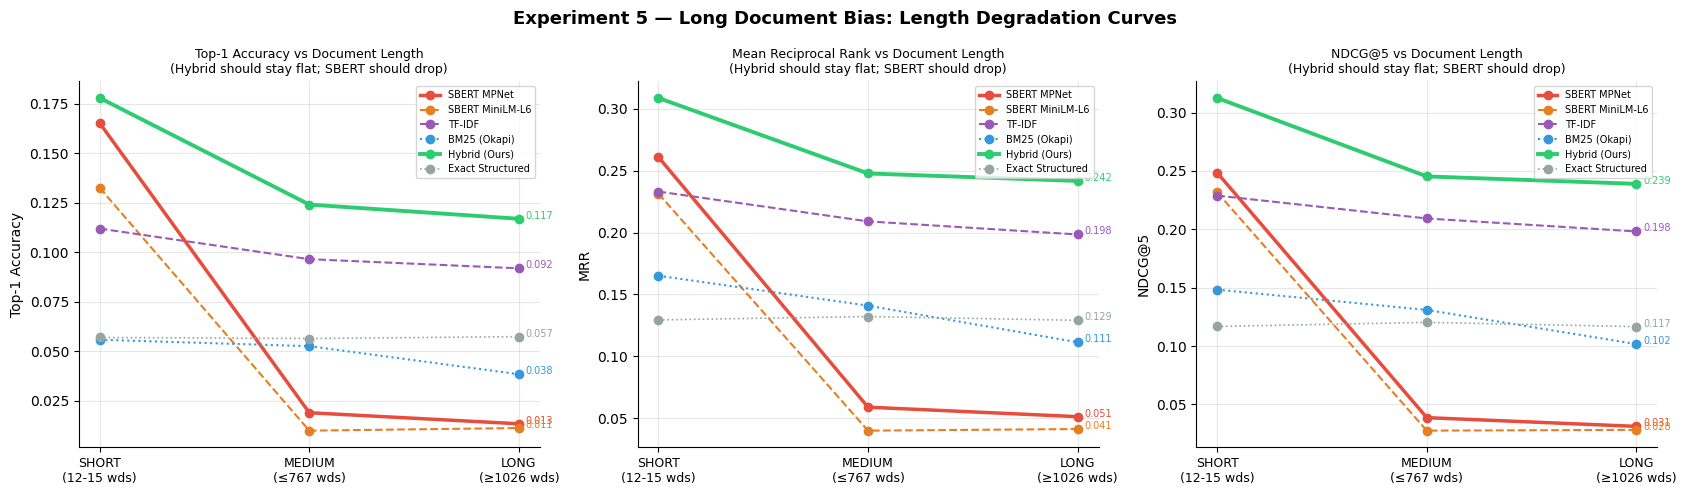

✅ Saved exp5_length_degradation.png


In [ ]:
# CELL 10 — VISUALISATION 1: LENGTH DEGRADATION CURVES
focus_models = [
    ('SBERT MPNet (sem-only)', '#e74c3c', '-',  2.5),
    ('SBERT MiniLM-L6',        '#e67e22', '--', 1.5),
    ('TF-IDF + Cosine',        '#9b59b6', '--', 1.5),
    ('BM25 (Okapi)',           '#3498db', ':',  1.5),
    ('Hybrid (Ours)',          '#2ecc71', '-',  2.8),
    ('Exact Structured',       '#95a5a6', ':',  1.2),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
x_labels = ['SHORT\n(12-15 wds)', f'MEDIUM\n(≤{WC_MED_MAX} wds)', f'LONG\n(≥{WC_LONG_MIN} wds)']
x_pos    = [0, 1, 2]

for ax, (col_s, col_m, col_l, ylabel, title) in zip(axes, [
    ('Short Top-1','Medium Top-1','Long Top-1', 'Top-1 Accuracy', 'Top-1 Accuracy'),
    ('Short MRR',  'Medium MRR',  'Long MRR',   'MRR',            'Mean Reciprocal Rank'),
    ('Short NDCG', 'Medium NDCG', 'Long NDCG',  'NDCG@5',         'NDCG@5'),
]):
    for model_name, color, ls, lw in focus_models:
        row = len_df[len_df['Model'] == model_name].iloc[0]
        vals = [row[col_s], row[col_m], row[col_l]]
        ax.plot(x_pos, vals, color=color, ls=ls, lw=lw, marker='o', ms=6,
                label=model_name.replace(' (sem-only)','').replace(' + Cosine',''))
        ax.annotate(f'{vals[2]:.3f}', (2, vals[2]), textcoords='offset points',
                    xytext=(5, 0), fontsize=7, color=color)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{title} vs Document Length\n(Hybrid should stay flat; SBERT should drop)', fontsize=9)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 5 — Long Document Bias: Length Degradation Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp5_length_degradation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp5_length_degradation.png')

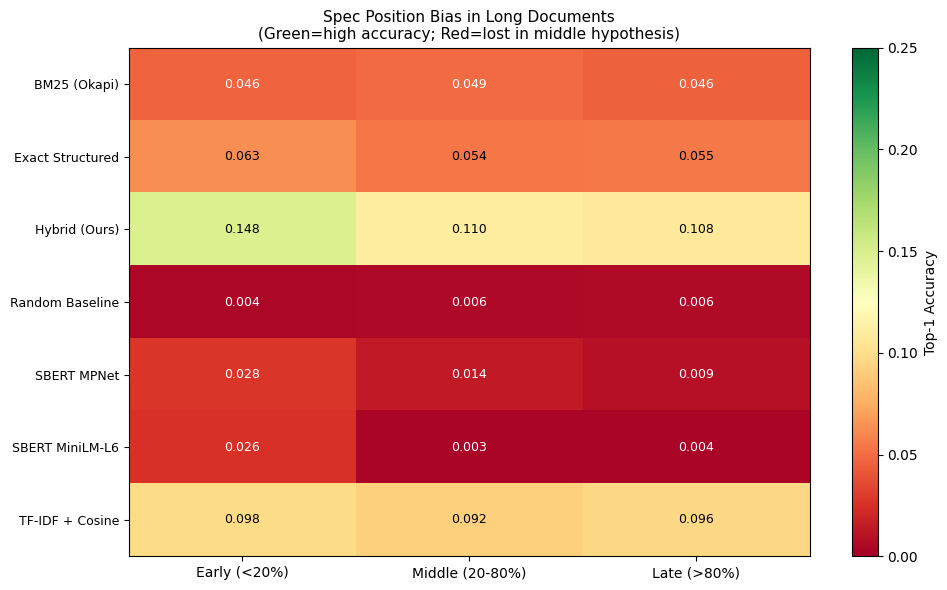

✅ Saved exp5_position_heatmap.png


In [ ]:
# CELL 11 — VISUALISATION 2: POSITION BIAS HEATMAP
pivot_top1 = pos_df.pivot(index='Model', columns='Position', values='Top-1')
# Order columns logically
cols_order = [c for c in ['Early (<20%)','Middle (20-80%)','Late (>80%)'] if c in pivot_top1.columns]
pivot_top1 = pivot_top1[cols_order]

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot_top1.values, cmap='RdYlGn', aspect='auto', vmin=0.0, vmax=0.25)
ax.set_xticks(range(len(cols_order)))
ax.set_xticklabels(cols_order, fontsize=10)
ax.set_yticks(range(len(pivot_top1.index)))
ax.set_yticklabels([m.replace(' (sem-only)','') for m in pivot_top1.index], fontsize=9)
for r in range(len(pivot_top1.index)):
    for c in range(len(cols_order)):
        val = pivot_top1.values[r, c]
        if not (val != val):  # not NaN
            ax.text(c, r, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color='black' if val > 0.05 else 'white')
plt.colorbar(im, ax=ax, label='Top-1 Accuracy')
ax.set_title('Spec Position Bias in Long Documents\n'
             '(Green=high accuracy; Red=lost in middle hypothesis)', fontsize=11)
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp5_position_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp5_position_heatmap.png')

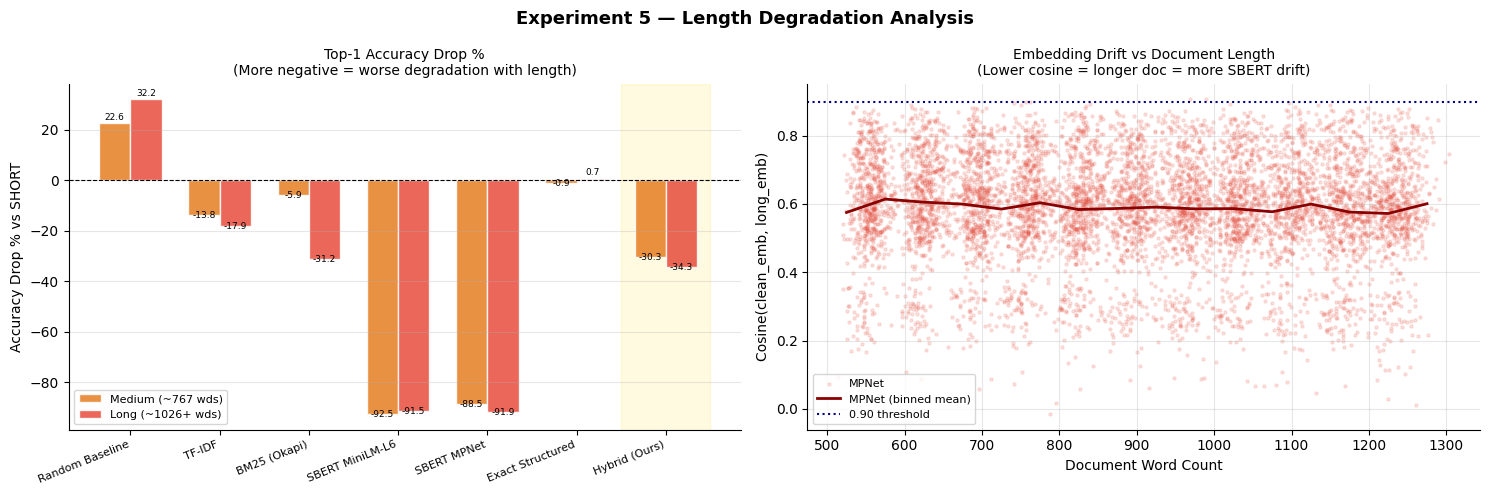

✅ Saved exp5_drop_and_drift.png


In [ ]:
# CELL 12 — VISUALISATION 3: ACCURACY DROP % BY LENGTH
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
models   = len_df['Model'].tolist()
x = np.arange(len(models))
w = 0.35
hybrid_x = [i for i, m in enumerate(models) if 'Hybrid' in m][0]

for ax, (col_med, col_long, title) in zip(axes, [
    ('Drop Med %', 'Drop Long %', 'Top-1 Accuracy Drop %'),
]):
    ax.bar(x-w/2, len_df[col_med].values, w, color='#e67e22', alpha=0.85,
           edgecolor='white', label=f'Medium (~{WC_MED_MAX} wds)')
    ax.bar(x+w/2, len_df[col_long].values, w, color='#e74c3c', alpha=0.85,
           edgecolor='white', label=f'Long (~{WC_LONG_MIN}+ wds)')
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.axvspan(hybrid_x-0.5, hybrid_x+0.5, color='gold', alpha=0.12, zorder=0)
    for i, (a,b) in enumerate(zip(len_df[col_med], len_df[col_long])):
        ax.text(i-w/2, a+(0.5 if a>=0 else -2), f'{a:.1f}', ha='center', va='bottom', fontsize=6.5)
        ax.text(i+w/2, b+(0.5 if b>=0 else -2), f'{b:.1f}', ha='center', va='bottom', fontsize=6.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (sem-only)','').replace(' + Cosine','') for m in models],
                        rotation=22, ha='right', fontsize=8)
    ax.set_ylabel('Accuracy Drop % vs SHORT')
    ax.set_title(f'{title}\n(More negative = worse degradation with length)', fontsize=10)
    ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

# Second panel: word count vs embedding cosine (SBERT drift)
cos_long_mpnet = np.sum(clean_emb_mpnet * long_emb_mpnet, axis=1)
axes[1].scatter(wc_long, cos_long_mpnet, alpha=0.15, s=5, color='#e74c3c', label='MPNet')
# Bin means
wc_bins = np.arange(500, 1350, 50)
bin_means = [cos_long_mpnet[(wc_long.values >= wc_bins[i]) & (wc_long.values < wc_bins[i+1])].mean()
             for i in range(len(wc_bins)-1)]
bin_centers = [(wc_bins[i]+wc_bins[i+1])/2 for i in range(len(wc_bins)-1)]
bin_means_clean = [v for v in bin_means if not (v!=v)]
bin_centers_clean = [bin_centers[i] for i,v in enumerate(bin_means) if not (v!=v)]
axes[1].plot(bin_centers_clean, bin_means_clean, color='darkred', lw=2, label='MPNet (binned mean)')
axes[1].axhline(0.90, color='navy', ls=':', lw=1.5, label='0.90 threshold')
axes[1].set_xlabel('Document Word Count')
axes[1].set_ylabel('Cosine(clean_emb, long_emb)')
axes[1].set_title('Embedding Drift vs Document Length\n'
                  '(Lower cosine = longer doc = more SBERT drift)', fontsize=10)
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 5 — Length Degradation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp5_drop_and_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp5_drop_and_drift.png')

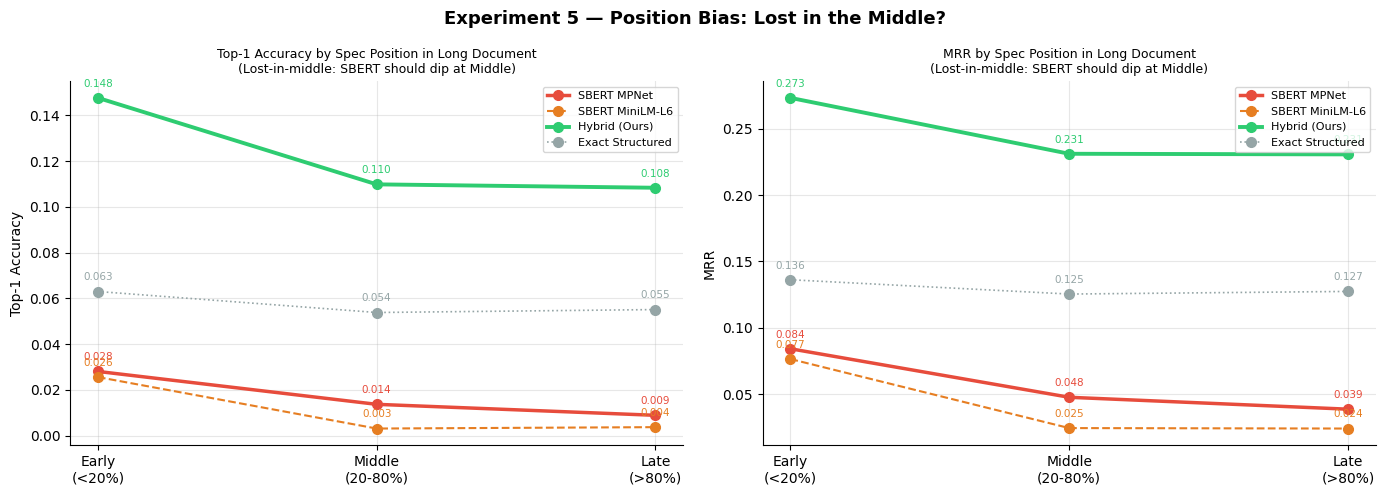

✅ Saved exp5_position_bias.png


In [ ]:
# CELL 13 — VISUALISATION 4: POSITION BIAS LINE PLOT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pos_focus = [
    ('SBERT MPNet (sem-only)', '#e74c3c', '-',  2.5),
    ('SBERT MiniLM-L6',        '#e67e22', '--', 1.5),
    ('Hybrid (Ours)',          '#2ecc71', '-',  2.8),
    ('Exact Structured',       '#95a5a6', ':',  1.2),
]
x_pos2   = [0, 1, 2]
x_labels2= ['Early\n(<20%)', 'Middle\n(20-80%)', 'Late\n(>80%)']

for ax, metric, ylabel in [
    (axes[0], 'Top-1', 'Top-1 Accuracy'),
    (axes[1], 'MRR',   'MRR'),
]:
    for model_name, color, ls, lw in pos_focus:
        sub = pos_df[pos_df['Model'] == model_name].sort_values('Position')
        positions_ordered = ['Early (<20%)','Middle (20-80%)','Late (>80%)']
        vals = [sub[sub['Position']==p][metric].values[0] if len(sub[sub['Position']==p]) > 0 else 0
                for p in positions_ordered]
        ax.plot(x_pos2, vals, color=color, ls=ls, lw=lw, marker='o', ms=7,
                label=model_name.replace(' (sem-only)',''))
        for xi, yi in zip(x_pos2, vals):
            ax.annotate(f'{yi:.3f}', (xi, yi), textcoords='offset points',
                        xytext=(0, 8), ha='center', fontsize=7.5, color=color)
    ax.set_xticks(x_pos2)
    ax.set_xticklabels(x_labels2, fontsize=10)
    ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} by Spec Position in Long Document\n'
                 '(Lost-in-middle: SBERT should dip at Middle)', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Experiment 5 — Position Bias: Lost in the Middle?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{EXP_DIR}/exp5_position_bias.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved exp5_position_bias.png')

In [ ]:
# CELL 14 — CONCRETE FAILURE CASES
print('=== Cases where SBERT fails on long docs but Hybrid holds ===\n')

def top1_sku(groups, rfp_id, sk):
    g = groups[rfp_id]
    return g['sku_id'][np.lexsort((g['sku_id'], -g[sk]))[0]]

hybrid_wins = [r for r in gt_lookup
               if top1_sku(groups_clean,r,'semantic') != top1_sku(groups_long,r,'semantic')
               and top1_sku(groups_clean,r,'hybrid')  == top1_sku(groups_long,r,'hybrid')]

print(f'RFPs: SBERT rank shifts on long doc, Hybrid stays stable: {len(hybrid_wins)}\n')

# Show examples across positions
for pos_name, pos_set in [('Early',set(pos_early)), ('Middle',set(pos_middle)), ('Late',set(pos_late))]:
    examples = [r for r in hybrid_wins if
                df_clean[df_clean['rfp_id']==r].index[0] in pos_set][:2]
    if not examples: continue
    print(f'--- {pos_name} spec position examples ---')
    for rfp_id in examples:
        idx = df_clean[df_clean['rfp_id']==rfp_id].index[0]
        clean_t = df_clean.loc[idx,'spec_text_raw']
        long_t  = df_long.loc[idx,'spec_text_raw']
        pos_val = spec_pos_arr[idx]
        wc_val  = wc_long.iloc[idx]
        spec_in_512 = spec_survives_truncation[idx]
        print(f'  RFP: {rfp_id}  WC={wc_val}  spec at {pos_val*100:.1f}%  spec_in_512={spec_in_512}')
        print(f'  CLEAN  : {clean_t}')
        print(f'  LONG (first 120 chars): {long_t[:120]}...')
        print(f'  LONG (last 100 chars): ...{long_t[-100:]}')
        print(f'  SBERT  clean={top1_sku(groups_clean,rfp_id,"semantic")}  long={top1_sku(groups_long,rfp_id,"semantic")}  X')
        print(f'  Hybrid clean={top1_sku(groups_clean,rfp_id,"hybrid")}  long={top1_sku(groups_long,rfp_id,"hybrid")}  OK')
        print()


In [ ]:
# CELL 15 — FINAL SUMMARY (PAPER-READY)
print('\n' + '='*115)
print('  EXPERIMENT 5 — LONG DOCUMENT BIAS TEST: COMPLETE RESULTS SUMMARY')
print('='*115)

print(f'\n-- Section A: Length Degradation (SHORT vs MEDIUM vs LONG) --')
print(f'   SHORT=clean 12-15 words  MEDIUM=long-doc WC<={WC_MED_MAX}  LONG=long-doc WC>={WC_LONG_MIN}')
print(len_df[['Model','Short Top-1','Medium Top-1','Drop Med %','Long Top-1','Drop Long %',
              'Short MRR','Medium MRR','Long MRR']]
      .to_markdown(index=False, floatfmt='.4f'))

print('\n-- Section B: Position Bias (SBERT MPNet vs Hybrid) --')
for model in ['SBERT MPNet (sem-only)', 'Hybrid (Ours)']:
    sub = pos_df[pos_df['Model'] == model][['Position','Top-1','MRR','n_eval']]
    print(f'  {model}:'); print(sub.to_string(index=False)); print()

print(f'-- Section C: Token Truncation --')
print(f'  Long docs exceeding 512-token SBERT limit: {exceed_512}/{N_RFP} ({exceed_512/N_RFP*100:.1f}%)')
print(f'  Spec truncated out of SBERT window:        {N_RFP-n_spec_survives}/{N_RFP} ({(N_RFP-n_spec_survives)/N_RFP*100:.1f}%)')
print(f'  Hybrid token truncation effect:            0% (reads structured cols only)')

h = len_df[len_df['Model']=='Hybrid (Ours)'].iloc[0]
s = len_df[len_df['Model']=='SBERT MPNet (sem-only)'].iloc[0]
h_ret_long = h['Long Top-1'] / h['Short Top-1'] * 100 if h['Short Top-1'] > 0 else 100
s_ret_long = s['Long Top-1'] / s['Short Top-1'] * 100 if s['Short Top-1'] > 0 else 100

print('\n-- Key Findings --')
print(f'  Hybrid retains {h_ret_long:.1f}% Top-1 on LONG docs (vs SHORT)')
print(f'  SBERT  retains {s_ret_long:.1f}% Top-1 on LONG docs (vs SHORT)')
print(f'  Hybrid/SBERT robustness ratio: {h_ret_long/s_ret_long:.2f}x')
print(f'  RFPs where SBERT shifts, Hybrid stable: {len(hybrid_wins)}')
print(f'\n  Cross-experiment summary:')
print(f'  Exp1 Wrong values:  SBERT 44.0%  Hybrid 85.6%  1.95x')
print(f'  Exp2 Unit notation: SBERT 76.6%  Hybrid 94.8%  1.24x')
print(f'  Exp3 Missing fields:SBERT 65.1%  Hybrid 89.2%  1.37x')
print(f'  Exp4 Noise:         SBERT 51.3%  Hybrid 88.6%  1.73x (in-domain)')
print(f'  Exp5 Long doc:      SBERT {s_ret_long:.1f}%  Hybrid {h_ret_long:.1f}%')


  EXPERIMENT 5 — LONG DOCUMENT BIAS TEST: COMPLETE RESULTS SUMMARY

-- Section A: Length Degradation (SHORT vs MEDIUM vs LONG) --
   SHORT=clean 12-15 words  MEDIUM=long-doc WC<=767  LONG=long-doc WC>=1026
| Model                  |   Short Top-1 |   Medium Top-1 |   Drop Med % |   Long Top-1 |   Drop Long % |   Short MRR |   Medium MRR |   Long MRR |
|:-----------------------|--------------:|---------------:|-------------:|-------------:|--------------:|------------:|-------------:|-----------:|
| Random Baseline        |        0.0046 |         0.0056 |      22.5754 |       0.0060 |       32.1752 |      0.0298 |       0.0286 |     0.0320 |
| TF-IDF + Cosine        |        0.1120 |         0.0966 |     -13.7931 |       0.0919 |      -17.9203 |      0.2331 |       0.2090 |     0.1984 |
| BM25 (Okapi)           |        0.0559 |         0.0526 |      -5.8559 |       0.0384 |      -31.2322 |      0.1651 |       0.1409 |     0.1113 |
| SBERT MiniLM-L6        |        0.1326 |         0.

In [ ]:
# CELL 16 — EXPORT
len_df.to_csv(f'{EXP_DIR}/exp5_length_stratified.csv', index=False)
pos_df.to_csv(f'{EXP_DIR}/exp5_position_analysis.csv', index=False)
pd.DataFrame({'rfp_id': df_clean['rfp_id'], 'spec_rel_pos': spec_pos_arr,
              'wc_long': wc_long, 'spec_in_512': spec_survives_truncation})\
  .to_csv(f'{EXP_DIR}/exp5_per_rfp_metadata.csv', index=False)
np.save(f'{EXP_DIR}/cos_clean_vs_long_mpnet.npy',
        np.sum(clean_emb_mpnet * long_emb_mpnet, axis=1))

print('✅ Saved:')
for fn in sorted(os.listdir(EXP_DIR)):
    size = os.path.getsize(f'{EXP_DIR}/{fn}') / 1024
    print(f'   {EXP_DIR}/{fn}  ({size:.0f} KB)')